# A notebook to train a RANDOM FOREST to perfom a PIXEL-based classification of (using AE Features) kontas_2017 dataset

## Import Usepackages

In [1]:
import torch
import gc

# Force clear everything
torch.cuda.empty_cache()
gc.collect()


import numpy as np
import seaborn as sns
import random
import cv2
import mlflow
import joblib

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data import TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, jaccard_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from mpl_toolkits.axes_grid1 import make_axes_locatable





## Pre-defined Functions

In [2]:
def patch_label(mask_patch: np.ndarray) -> int:
    """Return the most frequent class in a 16x16 mask patch."""
    values, counts = np.unique(mask_patch, return_counts=True)
    return int(values[np.argmax(counts)])

In [3]:
class PatchAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=16):
        super().__init__()

        # Encoder: 32 → 16 → 8 → 4
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),           # 8x8
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 32, 3, stride=2, padding=1),           # 4x4
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        # Bottleneck
        self.fc_latent = nn.Linear(32 * 4 * 4, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 32 * 4 * 4)

        # Decoder: 4 → 8 → 16 → 32
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 64, kernel_size=4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, in_channels, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.Sigmoid()
        )

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(-1, 32, 4, 4)
        return self.decoder(x)
    def encode(self, x):
        x = self.encoder(x)
        x = x.reshape(x.size(0), -1)  # was .view
        return self.fc_latent(x)
    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z        # return both for easy latent extraction

In [4]:
def train_autoencoder(model, train_loader, val_loader, epochs=30, lr=0.001):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0.0
        for images, _ in train_loader:          # labels ignored
            images = images.to(device)
            x_recon, _ = model(images)
            loss = criterion(x_recon, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                x_recon, _ = model(images)
                val_loss += criterion(x_recon, images).item()

        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        scheduler.step()

        print(f"Epoch {epoch+1}: train={train_loss:.6f}  val={val_loss:.6f}")
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_autoencoder.pth')

    model.load_state_dict(torch.load('best_autoencoder.pth'))
    return history

In [5]:
def extract_latents(model, loader):
    model.eval()
    latents, labels = [], []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            z = model.encode(images)            # (B, 16)
            latents.append(z.cpu().numpy())

            # majority vote label per patch
            patch_labels = [patch_label(m.squeeze().numpy()) for m in masks]
            labels.extend(patch_labels)

    return np.vstack(latents), np.array(labels)

In [6]:
def show_predicted_images(idxExample,imgExample,masks,pred_mask):

    cmap = ListedColormap(['black', 'blue', 'white'])

    fig, axes = plt.subplots(2, 3, figsize=(7, 5))

    axes[0,0].imshow(imgExample.squeeze())
    axes[0,0].set_title(f'Original Image {idxExample}')
    axes[0,0].axis('off')

    axes[0,1].imshow(masks[idxExample:idxExample+1].squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[0,1].set_title(f'Original Mask')
    axes[0,1].axis('off')

    axes[0,2].imshow(pred_mask.squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[0,2].set_title(f'Predicted Mask')
    axes[0,2].axis('off')



    diff = masks[idxExample].squeeze().astype(int) - pred_mask.squeeze().astype(int)

    im  = axes[1,2].imshow(diff, cmap='RdBu', vmin=-2, vmax=2)
    axes[1,2].set_title('Mask Differences')
    axes[1,2].axis('off')


    axes[1,0].axis('off')  # just turn it off — leaves it blank
    axes[1,1].axis('off')  # just turn it off — leaves it blank

    # Attach colorbar to axes[3] without stealing space from other plots
    divider = make_axes_locatable(axes[1,2])
    cax     = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax, ticks=[-2, -1, 0, 1, 2])


    unique, counts = np.unique(diff, return_counts=True)
    total = diff.size

    print(f"{'Value':>8} {'Count':>10} {'Percentage':>12}")
    print("-" * 32)
    for val, cnt in zip(unique, counts):
        print(f"{val:>8} {cnt:>10,} {cnt/total:>11.1%}")


def predict_mask_sliding(model, rf, image, patch_size=32, stride=8, n_classes=3):
    """
    model: your autoencoder (nn.Module)
    rf:    trained RandomForestClassifier
    image: np.array (H, W, C), values in [0, 1]
    Returns: predicted mask (H, W) with class indices
    """
    if image.max() > 1.0:
        image = image.astype(np.float32) / 255.0
    model.eval()
    H, W = image.shape[:2]

    # vote_map[r, c, class] = number of patches that voted for this class at pixel (r,c)
    vote_map = np.zeros((H, W, n_classes), dtype=np.int32)

    patches, coords = extract_patches_sliding(image, patch_size, stride)

    # Batch encode all patches
    batch_size = 64
    all_latents = []
    # Detect device from model
    device = next(model.parameters()).device
    with torch.no_grad():
        for i in range(0, len(patches), batch_size):
            batch = torch.tensor(patches[i:i+batch_size]).to(device)
            z = model.encode(batch)           # (B, latent_dim)
            all_latents.append(z.cpu().numpy())

    latents = np.concatenate(all_latents, axis=0)   # (N, latent_dim)
    predictions = rf.predict(latents)               # (N,)  class indices

    # Accumulate votes — every pixel covered by a patch gets one vote
    for (r, c), pred in zip(coords, predictions):
        vote_map[r:r+patch_size, c:c+patch_size, pred] += 1

    # Final label = class with most votes at each pixel
    mask = np.argmax(vote_map, axis=-1)   # (H, W)
    return mask

In [7]:
def extract_patches_sliding(image, patch_size=32, stride=8):
    """
    image: np.array (H, W, C) or tensor (C, H, W)
    Returns: patches (N, C, patch_size, patch_size), coords (N, 2) top-left (row, col)
    """
    if isinstance(image, torch.Tensor):
        image = image.numpy().transpose(1, 2, 0)  # C,H,W -> H,W,C

    H, W, C = image.shape
    patches, coords = [], []

    for r in range(0, H - patch_size + 1, stride):
        for c in range(0, W - patch_size + 1, stride):
            patch = image[r:r+patch_size, c:c+patch_size]          # (P, P, C)
            patch = patch.transpose(2, 0, 1).astype(np.float32)    # (C, P, P)
            patches.append(patch)
            coords.append((r, c))

    return np.stack(patches), coords  # (N, C, P, P), list of (r,c)


In [8]:
def predict_image_autoencodern(
    image: np.ndarray,
    clf,
    autoencoder,
    device,
    patch_size: int = 32,  # updated to match training
) -> np.ndarray:
    """
    Run a trained patch-based classifier on a single image,
    using autoencoder latent features.

    Args:
        image:       (H, W, C) float array, values in [0, 1]
        clf:         trained sklearn RandomForest (or any sklearn clf)
        autoencoder: trained PatchAutoencoder
        device:      torch device
        patch_size:  must match training (32)

    Returns:
        pred_mask:   (H, W) integer array of predicted class labels
    """
    if image.max() > 1.0:
        image = image.astype(np.float32) / 255.0

    H, W, C = image.shape
    n_ph = H // patch_size
    n_pw = W // patch_size

    # ── Extract patches ──────────────────────────────────────────────────────
    patches = []
    for pr in range(n_ph):
        for pc in range(n_pw):
            r0, r1 = pr * patch_size, (pr + 1) * patch_size
            c0, c1 = pc * patch_size, (pc + 1) * patch_size
            patches.append(image[r0:r1, c0:c1, :])   # (32, 32, C)

    # ── Encode through autoencoder ───────────────────────────────────────────
    patches_tensor = np.stack(patches, axis=0)         # (N, 32, 32, C)
    patches_tensor = (
        torch.from_numpy(patches_tensor)
        .permute(0, 3, 1, 2)                           # (N, C, 32, 32)
        .float()
        .to(device)
    )

    autoencoder.eval()
    with torch.no_grad():
        z = autoencoder.encode(patches_tensor)         # (N, 16)
    
    X = z.cpu().numpy()                                # (N, 16)

    # ── Classify ─────────────────────────────────────────────────────────────
    patch_preds = clf.predict(X)                       # (N,)

    # ── Reconstruct full-resolution mask ─────────────────────────────────────
    pred_mask = np.zeros((H, W), dtype=np.int64)
    idx = 0
    for pr in range(n_ph):
        for pc in range(n_pw):
            r0, r1 = pr * patch_size, (pr + 1) * patch_size
            c0, c1 = pc * patch_size, (pc + 1) * patch_size
            pred_mask[r0:r1, c0:c1] = patch_preds[idx]
            idx += 1

    return pred_mask

## Load Data

In [9]:
# Load in another notebook:
data   = np.load("datasetPatch.npz") #, images_patch=images_patch, masks_patch=masks_patch,all_masks=labs_patch)
images_patch = data["images_patch"].copy()  # force full load
masks_patch  = data["masks_patch"].copy()
labs_patch  = data["all_masks"].copy()
data.close()
del data

data   = np.load("dataset.npz") #np.savez("dataset.npz", images=images, masks=masks)
images = data["images"].copy()  # force full load
masks  = data["masks"].copy()
data.close()
del data



print("Number of images: ",len(images_patch))
print("Number of masks: ",len(masks_patch))
print(f" - Size of an image: {images_patch[0].shape}")
print(" - Size of a mask: ",masks_patch[0].shape)


Number of images:  394240
Number of masks:  394240
 - Size of an image: (32, 32, 3)
 - Size of a mask:  (32, 32)


## Train AutoEncoder

In [10]:
# Get data for the autoencoder
# Convert numpy → tensors once upfront
X = torch.from_numpy(images_patch).permute(0, 3, 1, 2).float() / 255.0  # (N, 3, H, W)
y = torch.from_numpy(masks_patch).unsqueeze(1).float()                    # (N, 1, H, W)

print(X.shape,y.shape)

# Split
dataset    = TensorDataset(X, y)
train_size = int(0.7 * len(dataset))
val_size   = int(0.2 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

print(f"\nTraining samples: {len(train_set):,}")
print(f"\nTraining samples: {len(test_set):,}")

# Dataloaders
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

torch.Size([394240, 3, 32, 32]) torch.Size([394240, 1, 32, 32])

Training samples: 275,968

Training samples: 39,424


In [11]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 1.13.1+cu117
CUDA available: True
Using device: cuda


In [12]:
# Train the autoencoder
print("Training autoencoder...")
autoencodern = PatchAutoencoder(in_channels=3, latent_dim=16).to(device)
print(f"Total parameters: {sum(p.numel() for p in autoencodern.parameters()):,}")
history = train_autoencoder(autoencodern, train_loader, val_loader, epochs=50, lr=0.0005)

Training autoencoder...


Total parameters: 122,387
Epoch 1: train=0.005683  val=0.001376
Epoch 2: train=0.001412  val=0.001118
Epoch 3: train=0.001156  val=0.000915
Epoch 4: train=0.001015  val=0.000802
Epoch 5: train=0.000946  val=0.000800
Epoch 6: train=0.000887  val=0.000853
Epoch 7: train=0.000876  val=0.000749
Epoch 8: train=0.000838  val=0.000738
Epoch 9: train=0.000818  val=0.000731
Epoch 10: train=0.000786  val=0.000739
Epoch 11: train=0.000774  val=0.000685
Epoch 12: train=0.000768  val=0.000831
Epoch 13: train=0.000740  val=0.000680
Epoch 14: train=0.000730  val=0.000723
Epoch 15: train=0.000735  val=0.000666
Epoch 16: train=0.000718  val=0.000667
Epoch 17: train=0.000714  val=0.000663
Epoch 18: train=0.000691  val=0.000640
Epoch 19: train=0.000697  val=0.000652
Epoch 20: train=0.000689  val=0.000634
Epoch 21: train=0.000678  val=0.000627
Epoch 22: train=0.000675  val=0.000639
Epoch 23: train=0.000674  val=0.000636
Epoch 24: train=0.000666  val=0.000629
Epoch 25: train=0.000670  val=0.000637
Epoch 26

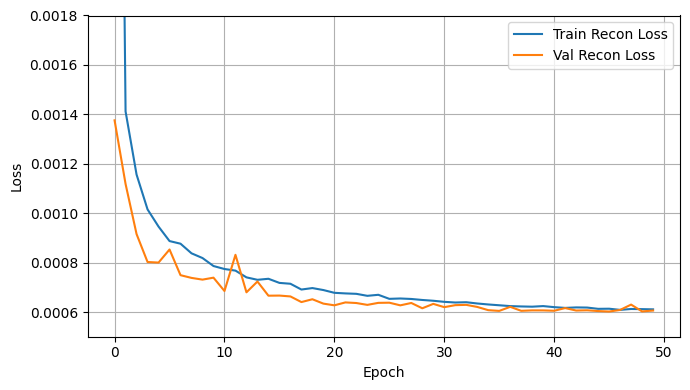

In [13]:
fig, axes = plt.subplots(figsize=(7, 4))

axes.plot(history['train_loss'], label='Train Recon Loss')
axes.plot(history['val_loss'], label='Val Recon Loss')
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')

axes.legend()
axes.grid(True)
axes.set_ylim([0.0005,0.0018])

plt.tight_layout()
plt.show()

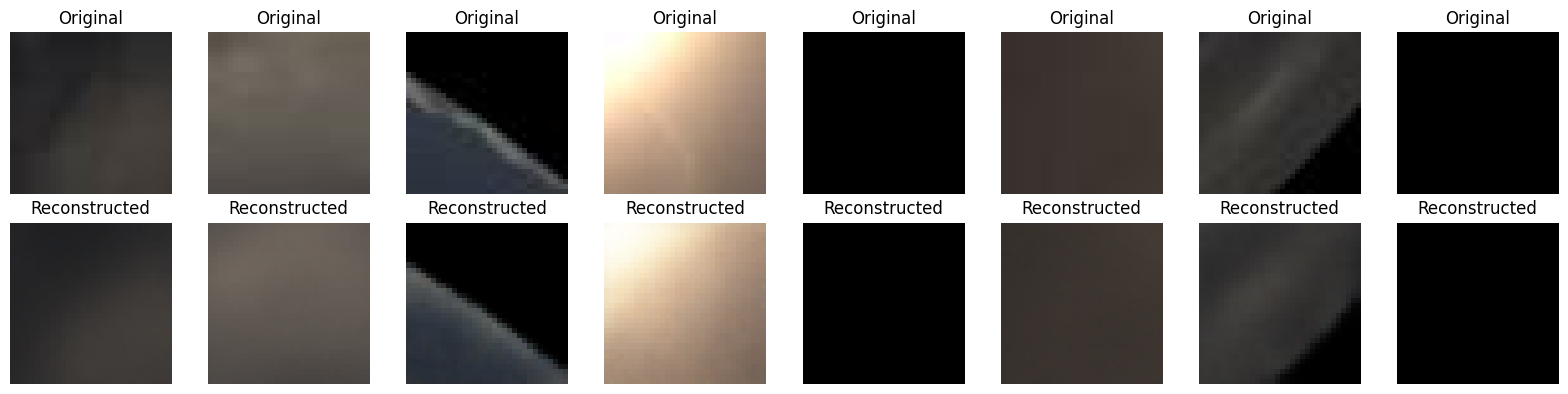

In [14]:
# Visualize reconstructions
autoencodern.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
     # Pick 8 random indices from the batch
    idx = np.random.choice(len(test_images), size=8, replace=False)
    test_images = test_images[idx].to(device)
    #reconstructed, _ = autoencoder2(test_images)
    reconstructed, _ = autoencodern(test_images)

    test_images = test_images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(min(8, len(test_images))):
    # Original
    axes[0, i].imshow(np.transpose(test_images[i], (1, 2, 0)))
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    
    # Reconstructed
    axes[1, i].imshow(np.transpose(reconstructed[i], (1, 2, 0)))
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Train Random Forest

In [15]:
# Extract and fit RF
print("Extract Features for Train, Validation and Test set....")
z_train, y_train = extract_latents(autoencodern, train_loader)
z_val,   y_val   = extract_latents(autoencodern, val_loader)
z_test,  y_test  = extract_latents(autoencodern, test_loader)

Extract Features for Train, Validation and Test set....


In [16]:
# Define architecture of Random Forest

# from RandomForest_Pixel_Hand-script
#The following hyperparameters are used:
#n_est=50, depth=30, maxFeature=sqrt, minSamplesSplit=20, minSampleLeaf=5

# from RandomForest_Pixel_Hand-script
n_est = 50
max_depth = 30
maxF = 'sqrt'
minSample = 20
minSampleLeaf = 5 

rfPatch = RandomForestClassifier(
    n_estimators=n_est,
    max_depth=max_depth,
    min_samples_split=minSample,
    min_samples_leaf=minSampleLeaf,
    max_features=maxF,
    verbose=1,
    n_jobs=-1, random_state=42,
    class_weight='balanced'
    )

In [17]:
rfPatch.fit(z_train, y_train)
print("Training complete!")
print(f"RF train accuracy: {rfPatch.score(z_train, y_train):.3f}")
print(f"RF test accuracy: {rfPatch.score(z_val, y_val):.3f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    5.5s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s


Training complete!
RF train accuracy: 0.951
RF test accuracy: 0.909


[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.2s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished



Random Forest Classification Report:
              precision    recall  f1-score   support

  Background       0.99      0.99      0.99      8634
   Clear Sky       0.93      0.88      0.90     18261
       Cloud       0.83      0.90      0.86     12529

    accuracy                           0.91     39424
   macro avg       0.92      0.92      0.92     39424
weighted avg       0.91      0.91      0.91     39424



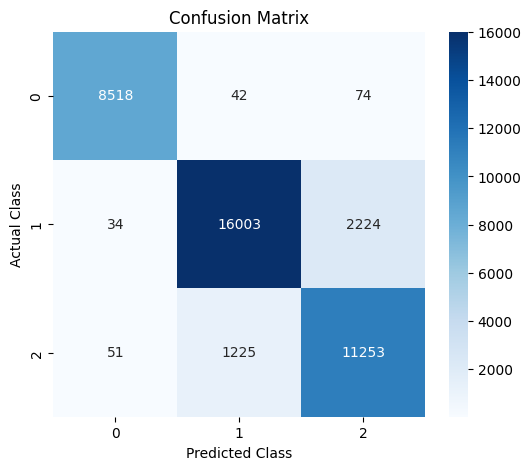

In [18]:
# Predictions
y_pred_patches = rfPatch.predict(z_test)


# Metrics
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_patches, 
                          target_names=['Background','Clear Sky', 'Cloud'],
                          zero_division=0))

cm = confusion_matrix(y_test, y_pred_patches)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2],
            yticklabels=[0,1,2])

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

/storage/homefs/lg19a108/myEnvLG/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/storage/homefs/lg19a108/myEnvLG/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


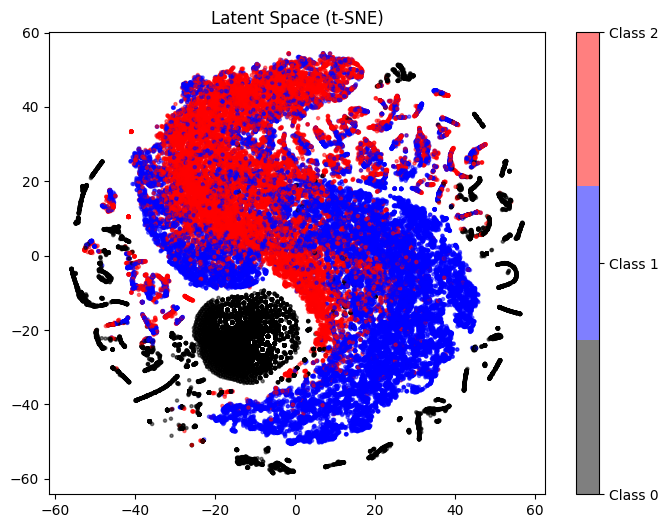

In [19]:
from sklearn.manifold import TSNE
import numpy as np

# Subsample to 5000 points max
n = min(68992, len(z_train))
idx = np.random.choice(len(z_train), n, replace=False)

z_2d = TSNE(n_components=2, random_state=42).fit_transform(z_train[idx])


cmap = ListedColormap(['black', 'blue', 'red'])
plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_train[idx], cmap=cmap, alpha=0.5, s=5)
cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.set_ticklabels(['Class 0', 'Class 1', 'Class 2'])
plt.title('Latent Space (t-SNE)')
plt.show()

## Feature Importance

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with

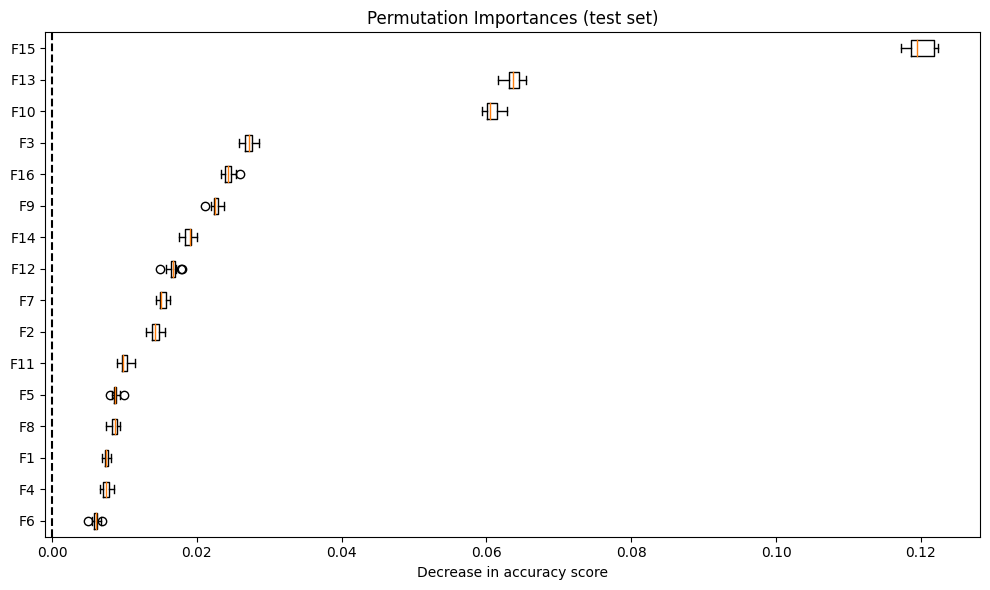

In [20]:
# Permutation Feature importance
feature_names = ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 
                 'F7', 'F8', 'F9', 'F10', 'F11', 
                 'F12', 'F13', 'F14', 'F15', 'F16']


result = permutation_importance(
    rfPatch, z_test, y_test, n_repeats=20, random_state=42, n_jobs=2
)

sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(result.importances[sorted_idx].T,
           vert=False,
           labels=np.array(feature_names)[sorted_idx])
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
fig.tight_layout()
plt.show()

## Image resp. Mask Reproduction

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


   Value      Count   Percentage
--------------------------------
      -2      3,915        1.5%
      -1     15,312        5.8%
       0    236,857       90.4%
       1      4,332        1.7%
       2      1,728        0.7%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


   Value      Count   Percentage
--------------------------------
      -2      6,027        2.3%
      -1         44        0.0%
       0    255,049       97.3%
       1          1        0.0%
       2      1,023        0.4%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


...

   Value      Count   Percentage
--------------------------------
      -2      4,460        1.7%
      -1     11,426        4.4%
       0    233,856       89.2%
       1     10,714        4.1%
       2      1,688        0.6%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


   Value      Count   Percentage
--------------------------------
      -2      5,070        1.9%
      -1     29,795       11.4%
       0    221,873       84.6%
       1      3,816        1.5%
       2      1,590        0.6%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


   Value      Count   Percentage
--------------------------------
      -2      1,835        0.7%
      -1     12,614        4.8%
       0    218,929       83.5%
       1     26,864       10.2%
       2      1,902        0.7%


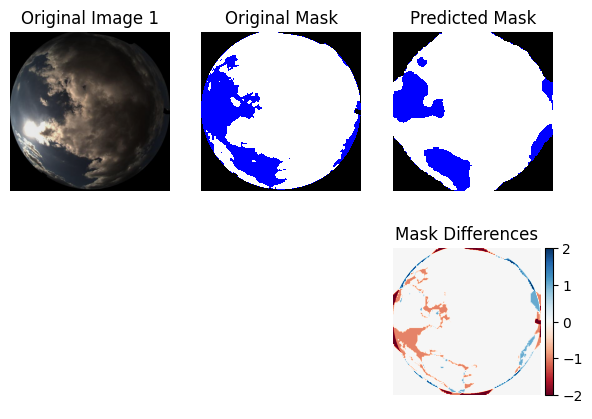

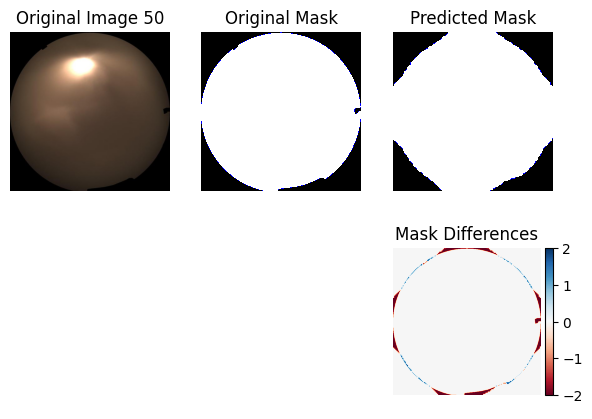

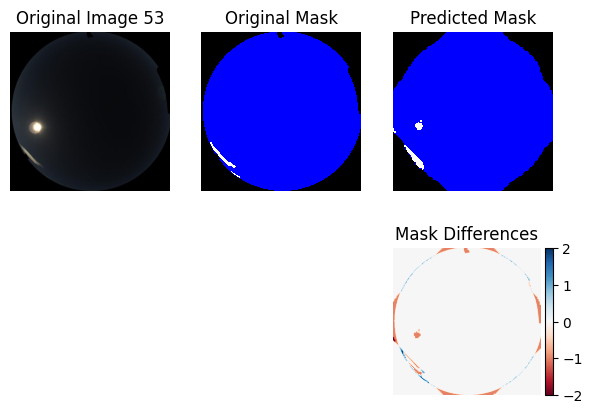

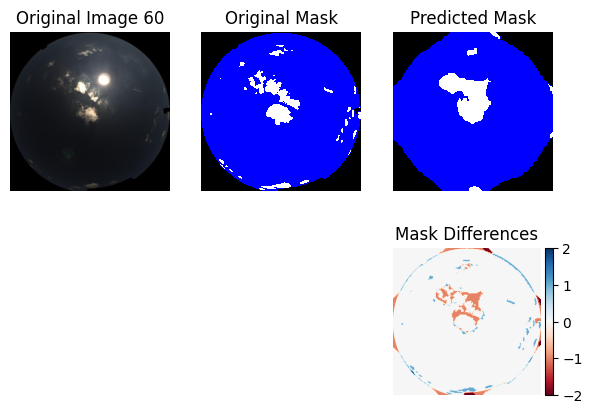

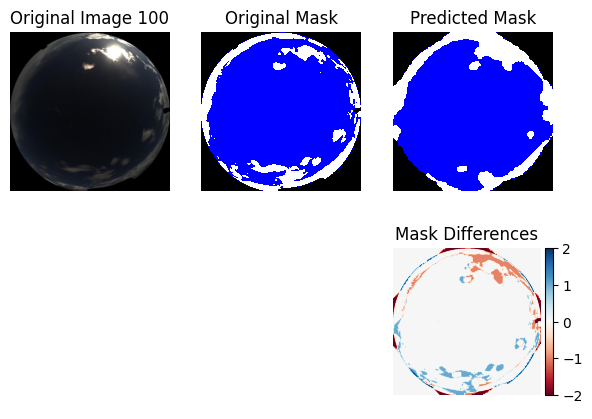

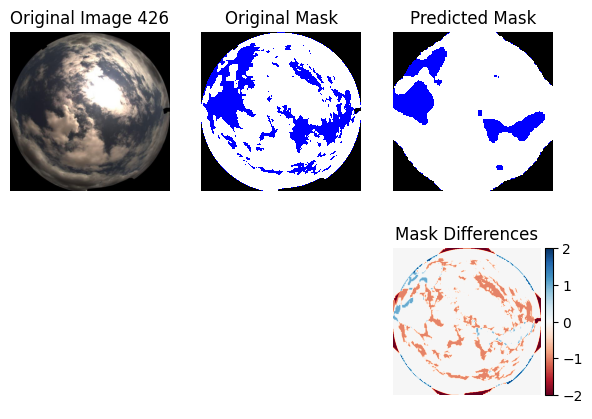

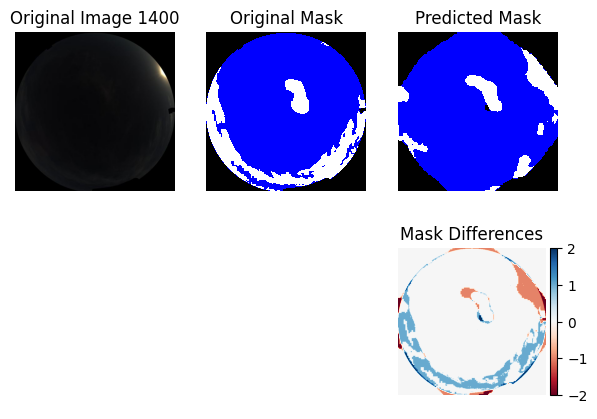

In [21]:
for idxExample in [1,50,53,60,100,426, 1400]:


    imgExample = images[idxExample:idxExample+1].squeeze(0)


    pred_mask = predict_image_autoencodern(
        image=imgExample,       # (512, 512, 3)
        clf=rfPatch,
        autoencoder=autoencodern,
        device=device,
        patch_size=32,
    )

    pred_mask_slid = predict_mask_sliding(
        autoencodern, rfPatch, imgExample,
        patch_size=32,
        stride=4,       # smaller = smoother edges, slower
        n_classes=3
    )

    # Visualize results

    show_predicted_images(idxExample,imgExample,masks,pred_mask_slid)

## Apply Random Forest on SwissOGS Images

In [29]:
# Define image and mask files
basePath = Path(r'SwissOGS')

# Append last_dir
image_path = basePath


image_paths = sorted(Path(image_path).glob("*.jpg"))

In [30]:
# Get data

imagesOGS = []

for idx, img_path in enumerate(image_paths):
    image = Image.open(img_path).convert("RGB")
    image.load()
    imagesOGS.append(image)

# Data set
imagesOGS = [np.array(img) for img in imagesOGS]

print("Number of images: ",len(imagesOGS))

print(" - Size of a image: ",imagesOGS[0].shape)

Number of images:  6
 - Size of a image:  (2822, 3044, 3)


In [31]:
def show_predicted_imagesOGS(idxExample,imgExample,pred_mask):

    cmap = ListedColormap(['black', 'blue', 'white'])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(np.array(imgExample))
    axes[0].set_title(f'Original Image {idxExample}')
    axes[0].axis('off')

    axes[1].imshow(pred_mask.squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[1].set_title(f'Predicted Mask')
    axes[1].axis('off')



<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


...

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.2s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.2s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.2s finished


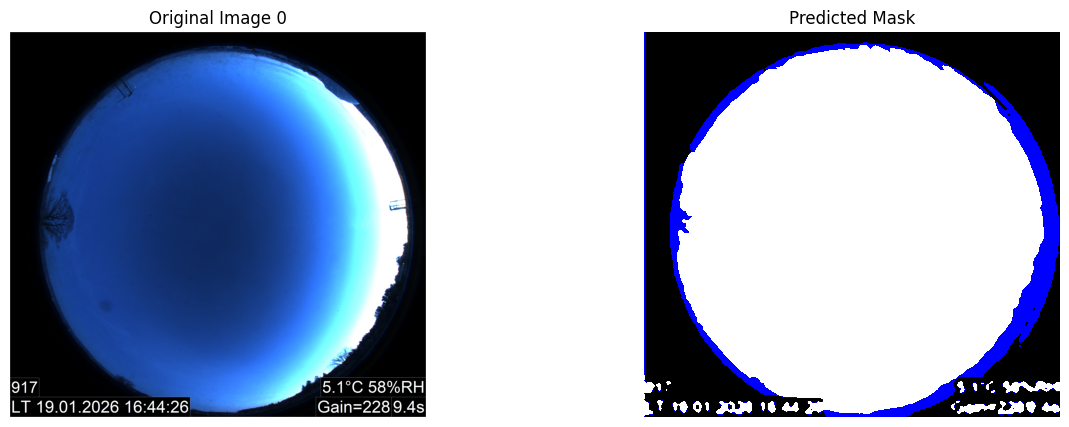

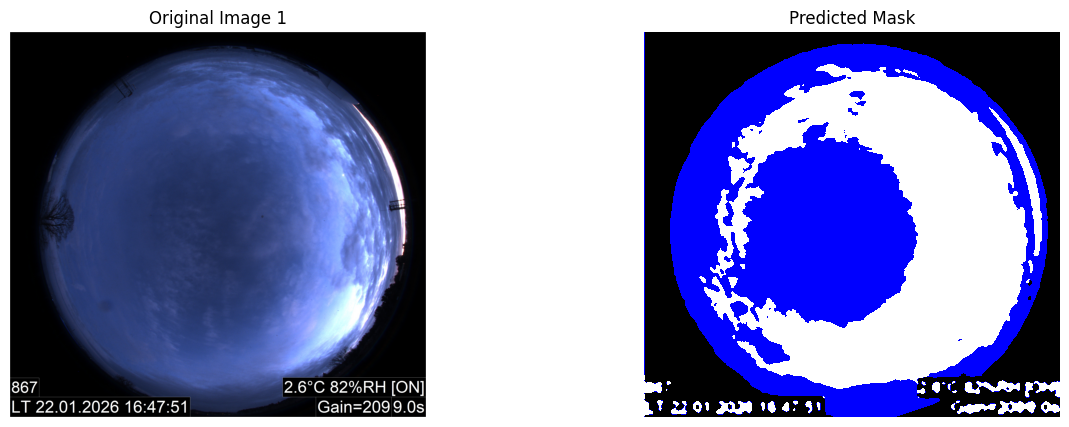

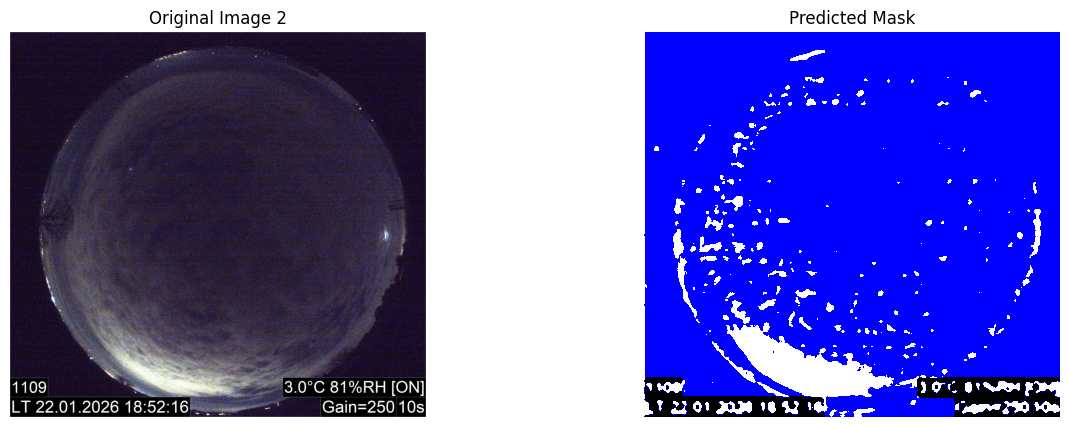

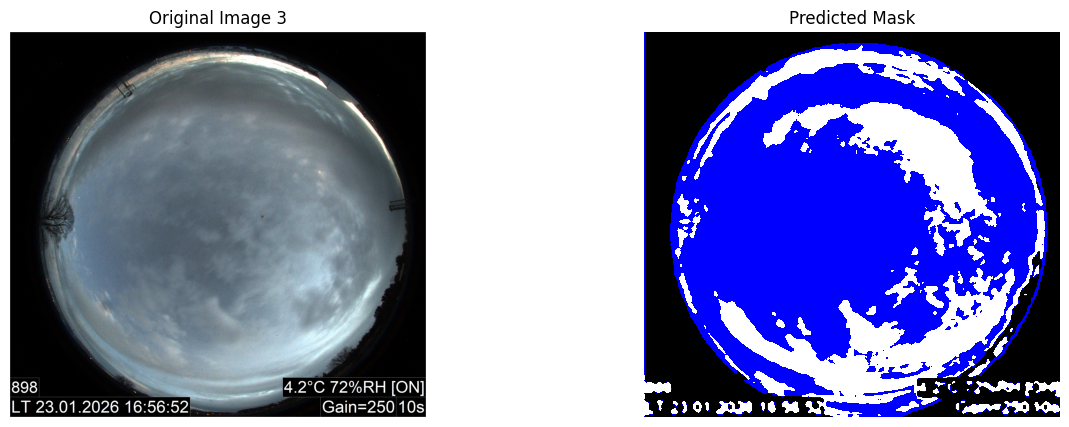

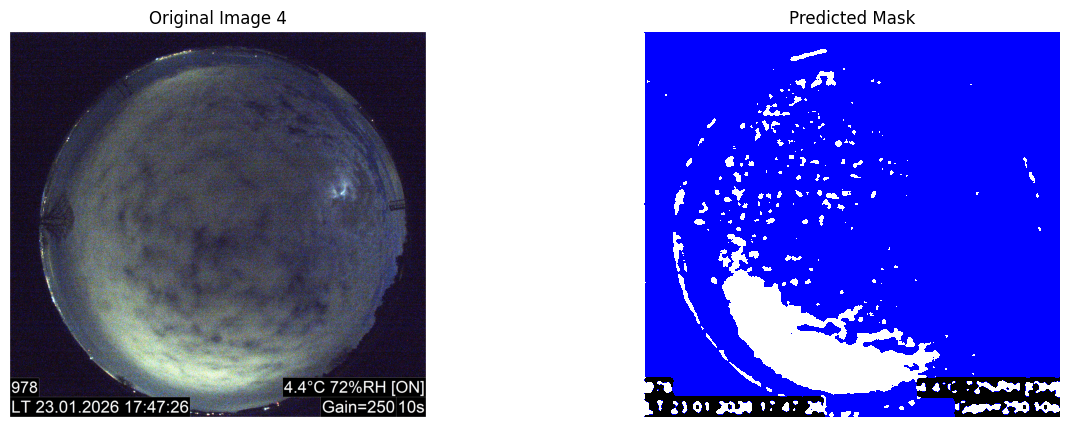

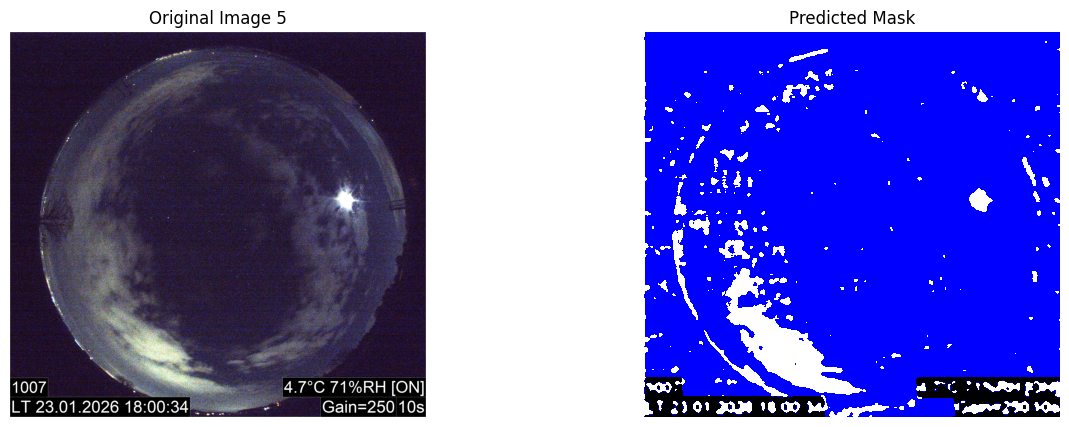

In [37]:
for idxExample in range(len(imagesOGS)):

    imgExample = imagesOGS[idxExample]
    print(type(imagesOGS[idxExample]), imagesOGS[idxExample].shape)


    # Visualize results  
    pred_mask_slid = predict_mask_sliding(
        autoencodern, rfPatch, imgExample,
        patch_size=32,
        stride=4,       # smaller = smoother edges, slower
        n_classes=3
    )


    show_predicted_imagesOGS(idxExample,imgExample,pred_mask_slid)

## Save the Model

In [ ]:
# Save trained model
joblib.dump(rfPatchAE, 'cloud_detection_rfAE.pkl')
print("Model saved!")

# Load model later with:
# rf_loaded = joblib.load('cloud_detection_rfAE.pkl')

Model saved!
